# Catcher Detection

Experimental notebook that was used to assist me in tuning the values for the catcher detection utilizing the pose detection model

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import math
import random

In [ ]:
# Load the data and create CSV

DOWNLOADS_PATH = 'data/downloads'

video_names = []

# Raw video intake
with os.scandir(os.path.join(os.path.dirname(os.getcwd()), DOWNLOADS_PATH)) as videos:
    for video in videos:
        video_names.append(video.path)

print(video_names)

In [ ]:
# can just pass the directory into ultralytics
VIDEO_DIRECTORY = '../data/downloads'

# for now we are only going to do a couple of videos from the directory

samples = []
for video in video_names[:3]:
    samples.append(video)

samples

In [2]:
# Load the pose model
model = YOLO('yolo26n-pose.pt')

In [3]:
# Run pose detection on one of the sample videos, and display the results in a window
results = model("/Users/tylerscaringella/Documents/Duke/CS372/Final Project/downloader/downloads/787583-34443691_CF.mp4", stream=True, save=True, show=True)

res = []

# Access the results
for result in results:
    # save the result of the pose detection and a copy of the frame so we can display later on
    res.append({
            "result": result,
            "frame": result.orig_img.copy()
        })
    
cv2.destroyAllWindows()


video 1/1 (frame 1/540) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/downloader/downloads/787583-34443691_CF.mp4: 384x640 5 persons, 70.5ms
video 1/1 (frame 2/540) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/downloader/downloads/787583-34443691_CF.mp4: 384x640 5 persons, 60.6ms
video 1/1 (frame 3/540) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/downloader/downloads/787583-34443691_CF.mp4: 384x640 5 persons, 51.7ms
video 1/1 (frame 4/540) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/downloader/downloads/787583-34443691_CF.mp4: 384x640 5 persons, 52.0ms
video 1/1 (frame 5/540) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/downloader/downloads/787583-34443691_CF.mp4: 384x640 5 persons, 75.7ms
video 1/1 (frame 6/540) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/downloader/downloads/787583-34443691_CF.mp4: 384x640 5 persons, 71.9ms
video 1/1 (frame 7/540) /Users/tylerscaringella/Documents/Duke/CS372/Final 

Frame gate: ok, count=4
reject i=0 reason=mostly_invalid_zone overlap=0.000 anchor_dist=0.362
reject i=1 reason=pitcher_like_low_tall_geometry overlap=0.769 anchor_dist=0.297
keep i=2 score=0.800 overlap=0.800 anchor_dist=0.306 knee=120.9 bottom=0.569
reject i=3 reason=hips_too_far_from_anchor overlap=0.512 anchor_dist=0.376
reject i=4 reason=knees_too_straight overlap=0.102 anchor_dist=0.422
Detected catcher: {'index': 2, 'box': array([      777.6,      275.67,      863.25,      409.44], dtype=float32), 'keypoints': array([[     811.35,      301.88],
       [     815.08,      297.43],
       [     807.25,      297.99],
       [     822.56,      296.93],
       [        801,      298.28],
       [        832,      313.52],
       [     794.55,      316.04],
       [     841.28,      339.88],
       [      793.3,      344.04],
       [     837.85,      356.16],
       [     807.61,       353.4],
       [     826.87,      363.44],
       [     801.19,      365.01],
       [     847.87,  

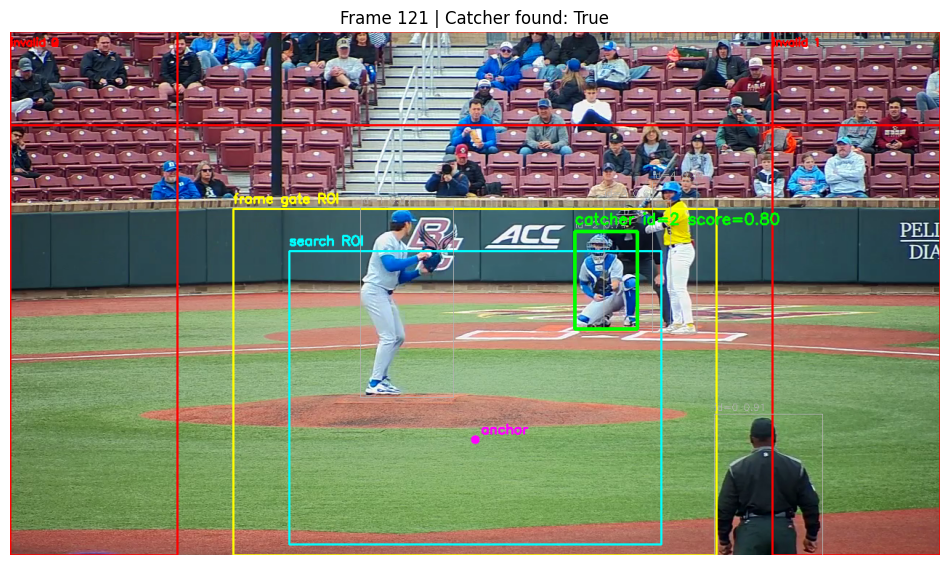

: 

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

import importlib
import catcher_detection
importlib.reload(catcher_detection)

from catcher_detection import CatcherDetectionConfig, detect_catcher_from_res_item

# Pick the frame index you want to inspect
FRAME_INDEX = 121

cfg = CatcherDetectionConfig(
    search_roi_norm=(0.30, 0.42, 0.70, 0.98),
    frame_gate_roi_norm=(0.24, 0.34, 0.76, 1.00),
    anchor_norm=(0.50, 0.78),
    invalid_zones_norm=[
        (0.00, 0.00, 0.18, 1.00),
        (0.82, 0.00, 1.00, 1.00),
        (0.00, 0.00, 1.00, 0.18),
    ],
    max_anchor_dist_norm=0.30,
    max_final_anchor_dist_norm=0.30,
    min_score=0.48,
    min_margin=0.0,
    min_aspect_ratio=0.70,
    max_compactness=2.30,
)

item = res[FRAME_INDEX]
frame = item["frame"].copy()
catcher = detect_catcher_from_res_item(item["result"], cfg=cfg, debug=True)

if catcher is None:
    print('catcher not detected')
else:
    print(f'Detected catcher: {catcher}')

h, w = frame.shape[:2]

def denorm_box(box_norm, w, h):
    x1, y1, x2, y2 = box_norm
    return (
        int(x1 * w), int(y1 * h),
        int(x2 * w), int(y2 * h)
    )

# Draw search ROI
rx1, ry1, rx2, ry2 = denorm_box(cfg.search_roi_norm, w, h)
cv2.rectangle(frame, (rx1, ry1), (rx2, ry2), (255, 255, 0), 2)
cv2.putText(frame, "search ROI", (rx1, max(20, ry1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

# Draw frame gate ROI
gx1, gy1, gx2, gy2 = denorm_box(cfg.frame_gate_roi_norm, w, h)
cv2.rectangle(frame, (gx1, gy1), (gx2, gy2), (0, 255, 255), 2)
cv2.putText(frame, "frame gate ROI", (gx1, max(20, gy1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

# Draw invalid zones
for j, zone in enumerate(cfg.invalid_zones_norm):
    zx1, zy1, zx2, zy2 = denorm_box(zone, w, h)
    cv2.rectangle(frame, (zx1, zy1), (zx2, zy2), (0, 0, 255), 2)
    cv2.putText(frame, f"invalid {j}", (zx1, min(h - 10, zy1 + 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# Draw anchor
ax, ay = int(cfg.anchor_norm[0] * w), int(cfg.anchor_norm[1] * h)
cv2.circle(frame, (ax, ay), 6, (255, 0, 255), -1)
cv2.putText(frame, "anchor", (ax + 8, ay - 8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)

# Draw all pose detections
result = item["result"]
boxes = result.boxes.xyxy.cpu().numpy()
confs = result.boxes.conf.cpu().numpy()

for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(frame, (x1, y1), (x2, y2), (180, 180, 180), 1)
    cv2.putText(frame, f"id={i} {confs[i]:.2f}", (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1)

# Highlight selected catcher
if catcher is not None:
    x1, y1, x2, y2 = catcher["box"].astype(int)
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(
        frame,
        f"catcher id={catcher['index']} score={catcher['score']:.2f}",
        (x1, max(25, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

# Convert BGR to RGB for matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title(f"Frame {FRAME_INDEX} | Catcher found: {catcher is not None}")
plt.axis("off")
plt.show()


Total frames:    540
Detected:        397
Missed / None:   143
Detection rate:  0.735


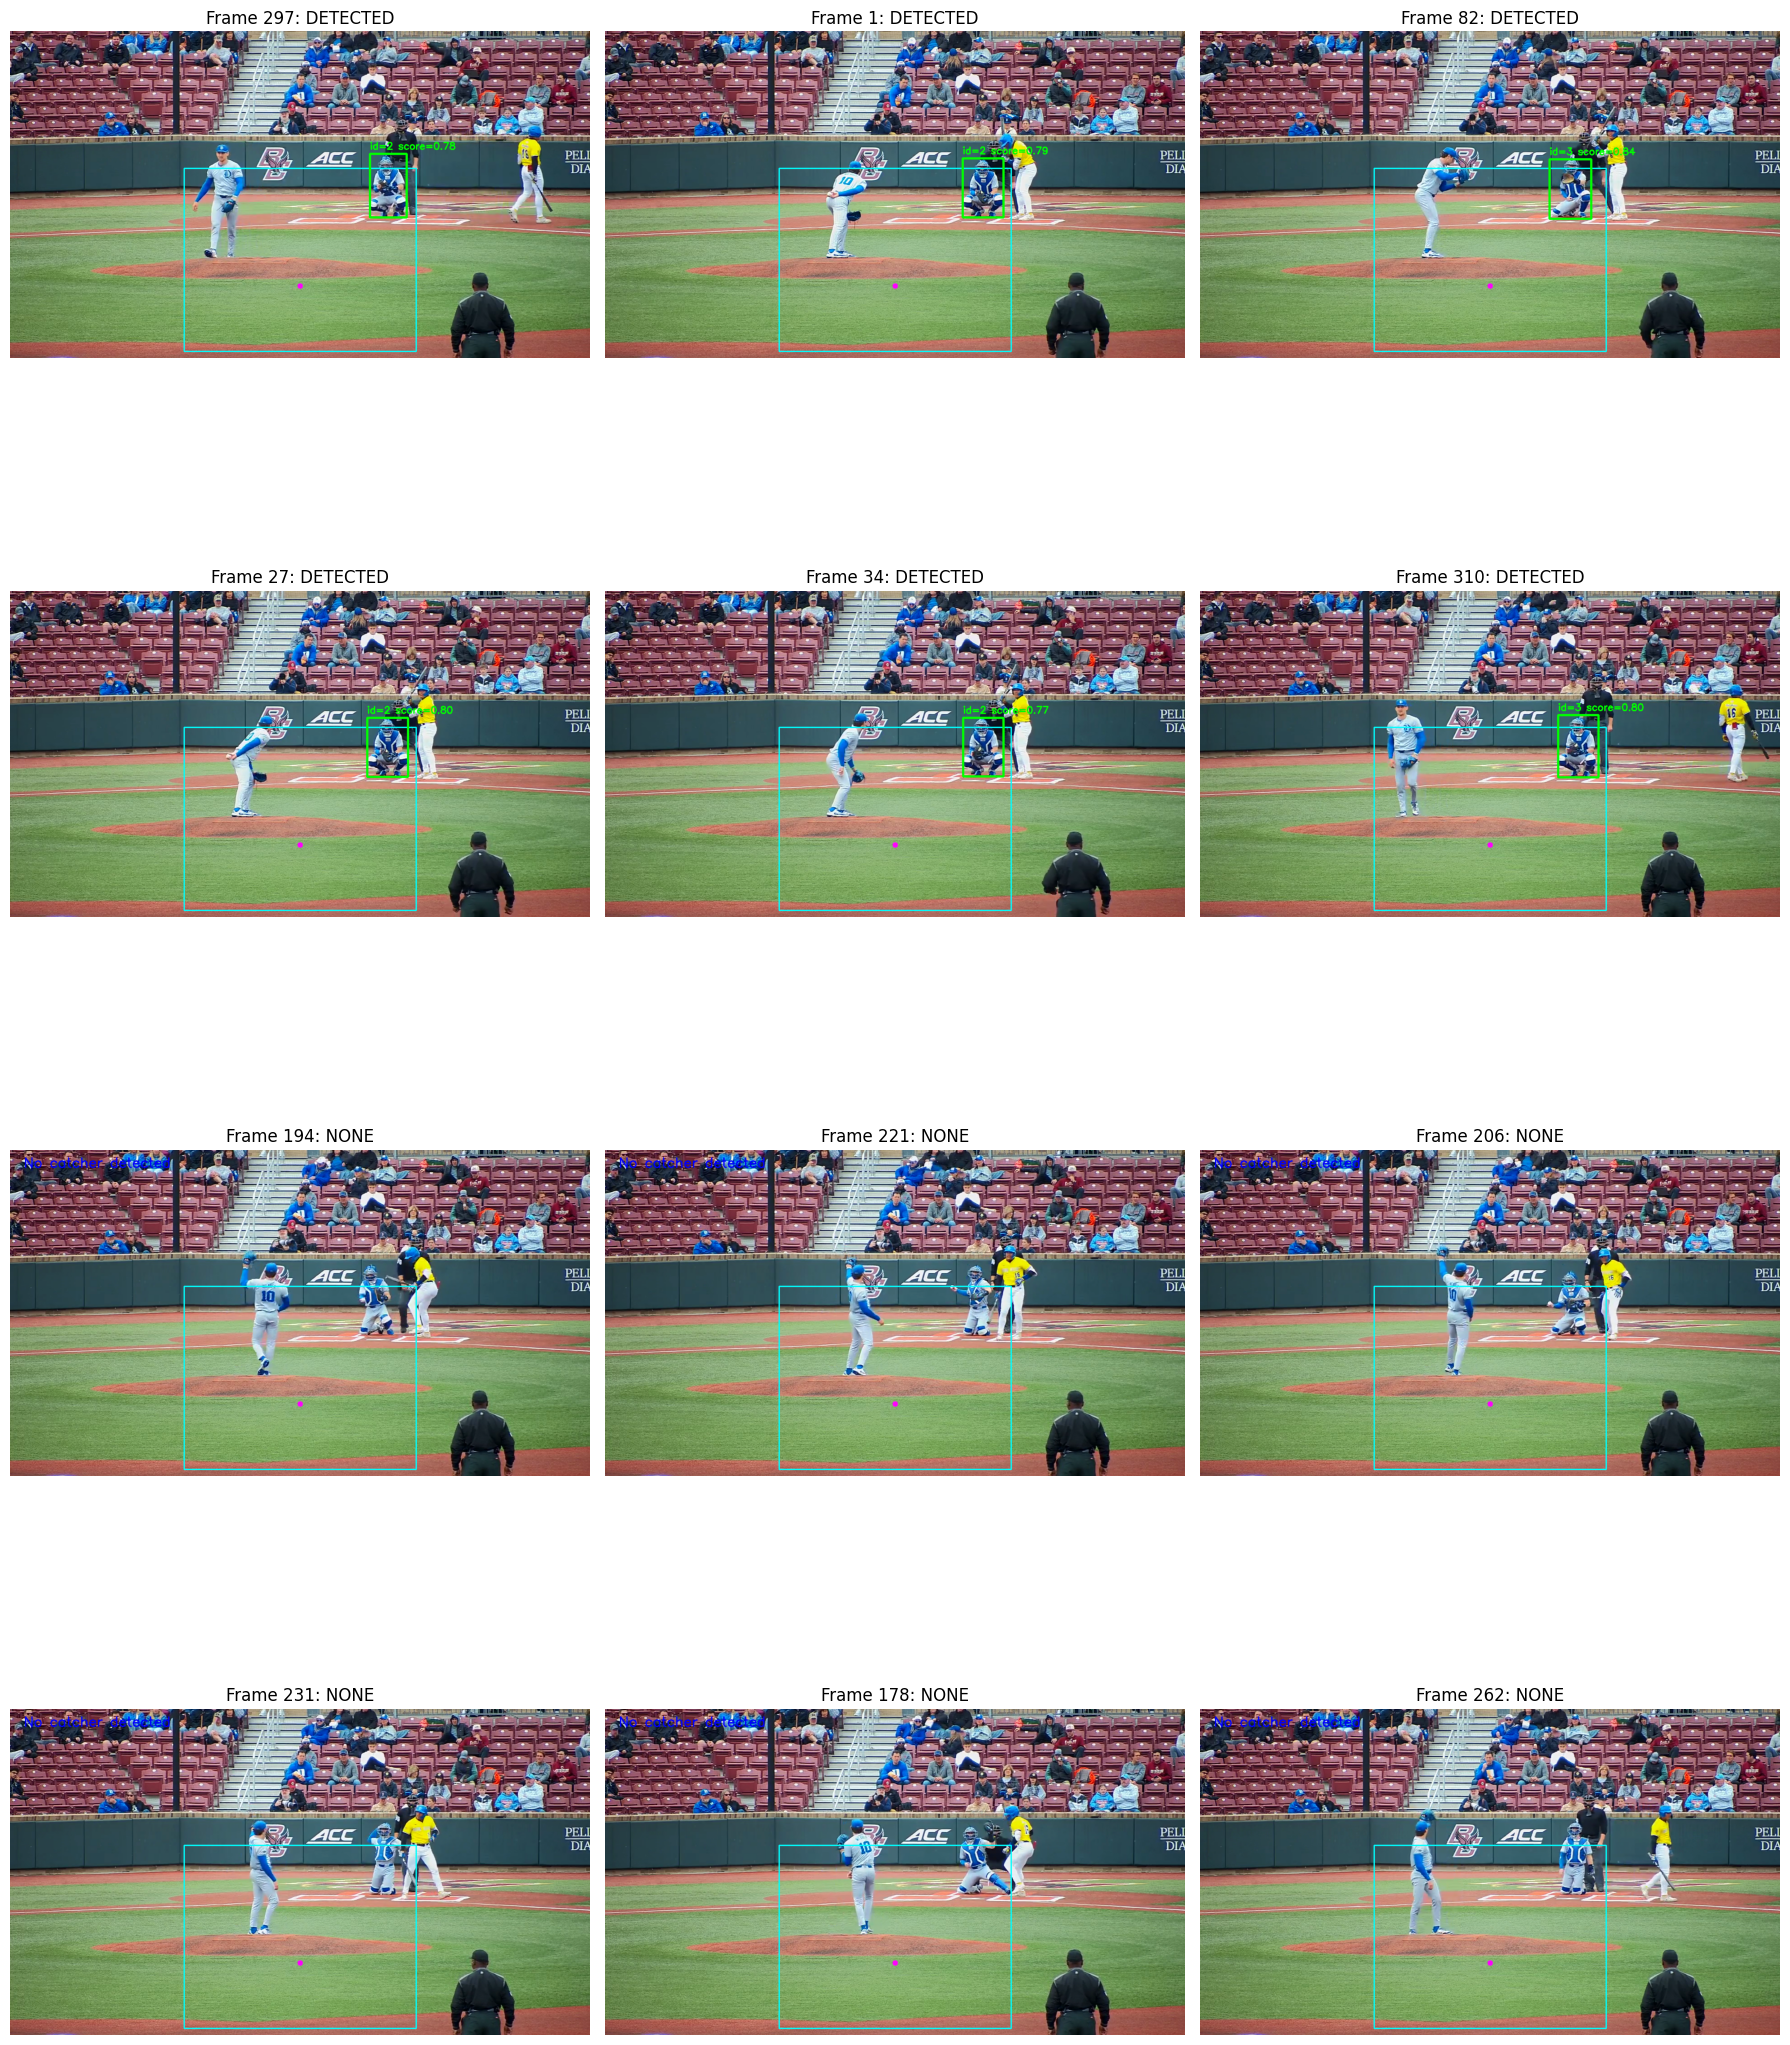

In [16]:
all_catcher_results = []
detected_indices = []
missed_indices = []

for i, item in enumerate(res):
    catcher = detect_catcher_from_res_item(item["result"], cfg=cfg, debug=False)
    all_catcher_results.append(catcher)
    if catcher is None:
        missed_indices.append(i)
    else:
        detected_indices.append(i)

print(f"Total frames:    {len(res)}")
print(f"Detected:        {len(detected_indices)}")
print(f"Missed / None:   {len(missed_indices)}")
print(f"Detection rate:  {len(detected_indices) / max(1, len(res)):.3f}")

def draw_catcher_debug(item, catcher, cfg, frame_index):
    frame = item["frame"].copy()
    h, w = frame.shape[:2]

    def denorm_box(box_norm):
        x1, y1, x2, y2 = box_norm
        return (
            int(x1 * w), int(y1 * h),
            int(x2 * w), int(y2 * h)
        )

    # Draw search ROI
    rx1, ry1, rx2, ry2 = denorm_box(cfg.search_roi_norm)
    cv2.rectangle(frame, (rx1, ry1), (rx2, ry2), (255, 255, 0), 2)

    # Draw anchor
    ax, ay = int(cfg.anchor_norm[0] * w), int(cfg.anchor_norm[1] * h)
    cv2.circle(frame, (ax, ay), 6, (255, 0, 255), -1)

    # Draw selected catcher if found
    if catcher is not None:
        x1, y1, x2, y2 = catcher["box"].astype(int)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(
            frame,
            f"id={catcher['index']} score={catcher['score']:.2f}",
            (x1, max(25, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )
        title = f"Frame {frame_index}: DETECTED"
    else:
        cv2.putText(
            frame,
            "No catcher detected",
            (30, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 0, 0),
            2
        )
        title = f"Frame {frame_index}: NONE"

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame_rgb, title

# Show a sample of frames
num_detected_to_show = 6
num_missed_to_show = 6

sample_detected = random.sample(detected_indices, min(num_detected_to_show, len(detected_indices)))
sample_missed = random.sample(missed_indices, min(num_missed_to_show, len(missed_indices)))

sample_indices = sample_detected + sample_missed

if sample_indices:
    cols = 3
    rows = math.ceil(len(sample_indices) / cols)
    plt.figure(figsize=(18, 6 * rows))

    for plot_idx, frame_idx in enumerate(sample_indices, start=1):
        frame_rgb, title = draw_catcher_debug(
            res[frame_idx],
            all_catcher_results[frame_idx],
            cfg,
            frame_idx
        )
        plt.subplot(rows, cols, plot_idx)
        plt.imshow(frame_rgb)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No frames available to display.")


In [ ]:
import cv2
import matplotlib.pyplot as plt

from catcher_detection import candidate_rejection_reason, detect_catcher_from_res_item

FRAME_INDEX = 119 # change to 145 after

item = res[FRAME_INDEX]
result = item["result"]
frame = item["frame"].copy()

boxes = result.boxes.xyxy.cpu().numpy()
confs = result.boxes.conf.cpu().numpy()
keypoints = result.keypoints.xy.cpu().numpy()
frame_shape = frame.shape[:2]

catcher = detect_catcher_from_res_item(item["result"], cfg=cfg, debug=True)
print("\nFINAL PICK:")
print(catcher["index"] if catcher is not None else None)

for i, box in enumerate(boxes):
    reason, meta = candidate_rejection_reason(
        box=box,
        conf=float(confs[i]),
        kpts=keypoints[i],
        frame_shape=frame_shape,
        cfg=cfg,
    )
    f = meta["features"]

    x1, y1, x2, y2 = box.astype(int)
    color = (0, 255, 0) if catcher is not None and i == catcher["index"] else (180, 180, 180)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    cv2.putText(
        frame,
        f"id={i} {'KEPT' if reason is None else reason}",
        (x1, max(20, y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        color,
        1,
    )

    print("\n---")
    print("i:", i)
    print("reason:", reason or "kept")
    print("conf:", float(confs[i]))
    print("box:", box.tolist())
    print("search_overlap:", meta["search_overlap"])
    print("anchor_dist_norm:", meta["anchor_dist_norm"])
    print("hip_anchor_dx_norm:", meta["hip_anchor_dx_norm"])
    print("invalid_overlap:", meta["invalid_overlap"])
    print("avg_knee_angle:", f["avg_knee_angle"])
    print("bottom_y_norm:", f["bottom_y_norm"])
    print("box_h_norm:", f["box_h_norm"])
    print("aspect_ratio:", f["aspect_ratio"])
    print("compactness:", f["compactness"])
    print("width_ratio:", f["width_ratio"])
    print("shoulder_to_ankle_dx_norm:", f["shoulder_to_ankle_dx_norm"])
    print("hip_center_x_norm:", f["hip_center_x_norm"])
    print("hip_center_y_norm:", f["hip_center_y_norm"])
    print("center_x_norm:", f["center_x_norm"])
    print("center_y_norm:", f["center_y_norm"])

# draw search ROI + anchor
h, w = frame.shape[:2]
rx1, ry1, rx2, ry2 = (
    int(cfg.search_roi_norm[0] * w),
    int(cfg.search_roi_norm[1] * h),
    int(cfg.search_roi_norm[2] * w),
    int(cfg.search_roi_norm[3] * h),
)
cv2.rectangle(frame, (rx1, ry1), (rx2, ry2), (255, 255, 0), 2)

ax, ay = int(cfg.anchor_norm[0] * w), int(cfg.anchor_norm[1] * h)
cv2.circle(frame, (ax, ay), 6, (255, 0, 255), -1)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f"Frame {FRAME_INDEX}")
plt.axis("off")
plt.show()


In [ ]:
FRAME_INDEX = 119
TRUE_CATCHER_ID = 2   # replace after you identify it

item = res[FRAME_INDEX]
result = item["result"]
boxes = result.boxes.xyxy.cpu().numpy()
confs = result.boxes.conf.cpu().numpy()
keypoints = result.keypoints.xy.cpu().numpy()
frame_shape = item["frame"].shape[:2]

reason, meta = candidate_rejection_reason(
    box=boxes[TRUE_CATCHER_ID],
    conf=float(confs[TRUE_CATCHER_ID]),
    kpts=keypoints[TRUE_CATCHER_ID],
    frame_shape=frame_shape,
    cfg=cfg,
)

f = meta["features"]

print("TRUE CATCHER ID:", TRUE_CATCHER_ID)
print("reason:", reason or "kept")
print("conf:", float(confs[TRUE_CATCHER_ID]))
print("box:", boxes[TRUE_CATCHER_ID].tolist())
print("search_overlap:", meta["search_overlap"])
print("anchor_dist_norm:", meta["anchor_dist_norm"])
print("hip_anchor_dx_norm:", meta["hip_anchor_dx_norm"])
print("invalid_overlap:", meta["invalid_overlap"])
print("avg_knee_angle:", f["avg_knee_angle"])
print("bottom_y_norm:", f["bottom_y_norm"])
print("box_h_norm:", f["box_h_norm"])
print("aspect_ratio:", f["aspect_ratio"])
print("compactness:", f["compactness"])
print("width_ratio:", f["width_ratio"])
print("shoulder_to_ankle_dx_norm:", f["shoulder_to_ankle_dx_norm"])
print("hip_center_x_norm:", f["hip_center_x_norm"])
print("hip_center_y_norm:", f["hip_center_y_norm"])
print("center_x_norm:", f["center_x_norm"])
print("center_y_norm:", f["center_y_norm"])


In [14]:
import cv2
from pathlib import Path

from catcher_detection import CatcherDetectionConfig, detect_catcher_from_res_item

OUTPUT_VIDEO = "catcher_detection_annotated.mp4"
FPS = 30  # change if needed

first_frame = res[0]["frame"]
h, w = first_frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, FPS, (w, h))

for i, item in enumerate(res):
    frame = item["frame"].copy()
    catcher = detect_catcher_from_res_item(item["result"], cfg=cfg, debug=False)

    # Draw search ROI
    rx1 = int(cfg.search_roi_norm[0] * w)
    ry1 = int(cfg.search_roi_norm[1] * h)
    rx2 = int(cfg.search_roi_norm[2] * w)
    ry2 = int(cfg.search_roi_norm[3] * h)
    cv2.rectangle(frame, (rx1, ry1), (rx2, ry2), (255, 255, 0), 2)

    # Draw anchor
    ax = int(cfg.anchor_norm[0] * w)
    ay = int(cfg.anchor_norm[1] * h)
    cv2.circle(frame, (ax, ay), 6, (255, 0, 255), -1)

    # Frame label
    cv2.putText(
        frame,
        f"Frame {i}",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 255),
        2,
    )

    if catcher is not None:
        x1, y1, x2, y2 = catcher["box"].astype(int)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)

        label = (
            f"Catcher id={catcher['index']} "
            f"score={catcher['score']:.2f} "
            f"margin={catcher['margin']:.2f}"
        )
        cv2.putText(
            frame,
            label,
            (x1, max(25, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
        )
    else:
        cv2.putText(
            frame,
            "No catcher detected",
            (20, 75),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            2,
        )

    writer.write(frame)

writer.release()
print(f"Saved annotated video to: {Path(OUTPUT_VIDEO).resolve()}")


Saved annotated video to: /Users/tylerscaringella/Documents/Duke/CS372/Final Project/notebook/catcher_detection_annotated.mp4


In [ ]:
FRAME_INDEX = 119
item = res[FRAME_INDEX]
catcher = detect_catcher_from_res_item(item["result"], cfg=cfg, debug=False)

# print all kept candidates and their score parts
for cand in catcher["all_candidates"]:
    print("\n---")
    print("index:", cand["index"])
    print("score:", cand["score"])
    print("score_parts:", cand["score_parts"])


In [ ]:
from catcher_detection import candidate_rejection_reason, score_candidate

FRAME_INDEX = 119
item = res[FRAME_INDEX]

catcher = detect_catcher_from_res_item(item["result"], cfg=cfg, debug=True)

print("\nFINAL RESULT:")
print(catcher)

result = item["result"]
boxes = result.boxes.xyxy.cpu().numpy()
confs = result.boxes.conf.cpu().numpy()
keypoints = result.keypoints.xy.cpu().numpy()
frame_shape = item["frame"].shape[:2]

for target_id in [0, 2]:
    reason, meta = candidate_rejection_reason(
        box=boxes[target_id],
        conf=float(confs[target_id]),
        kpts=keypoints[target_id],
        frame_shape=frame_shape,
        cfg=cfg,
    )
    print("\n====================")
    print("target_id:", target_id)
    print("reason:", reason or "kept")
    if reason is None:
        score_parts = score_candidate(meta=meta, conf=float(confs[target_id]), cfg=cfg)
        print("score_parts:", score_parts)
